In [1]:
import pandas as pd

df = pd.read_csv("Advertising.csv")

print(df.head())

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [2]:
print(df.shape)
print(df.columns)

(200, 5)
Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [4]:
print(df.isnull().sum())

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [5]:
df = df.drop('Unnamed: 0', axis=1)

print(df.head())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9


In [6]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (200, 3)
Target shape: (200,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 160
Testing samples: 40


In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [10]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [11]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)

print("R² Score:", score)

R² Score: 0.899438024100912


In [12]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.4607567168117608


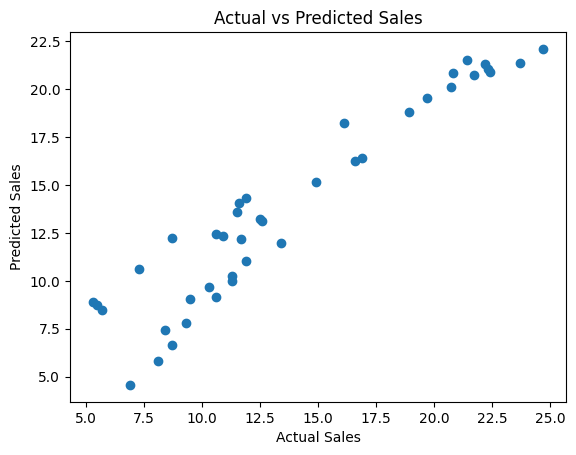

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

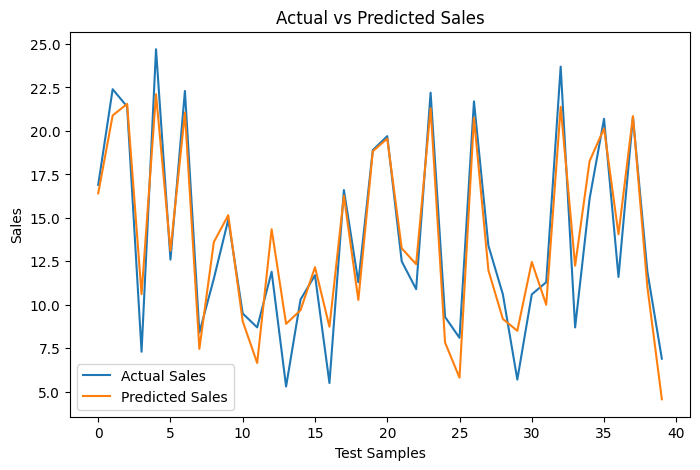

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(len(y_test)), y_test.values, label='Actual Sales')
plt.plot(range(len(y_pred)), y_pred, label='Predicted Sales')

plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Samples")
plt.ylabel("Sales")
plt.legend()

plt.show()

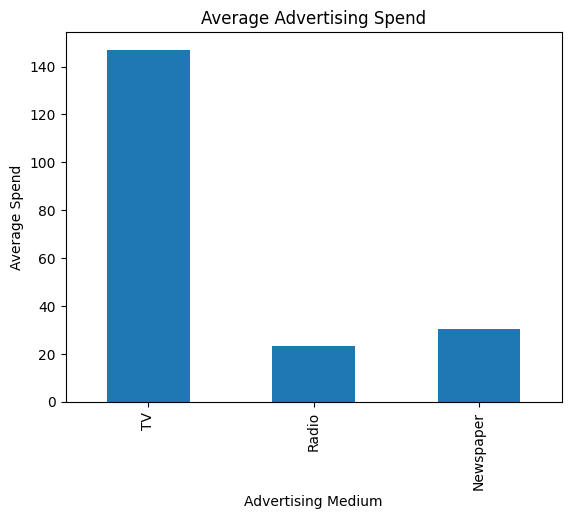

In [15]:
import matplotlib.pyplot as plt

avg_spend = df[['TV', 'Radio', 'Newspaper']].mean()

avg_spend.plot(kind='bar')

plt.title("Average Advertising Spend")
plt.xlabel("Advertising Medium")
plt.ylabel("Average Spend")
plt.show()

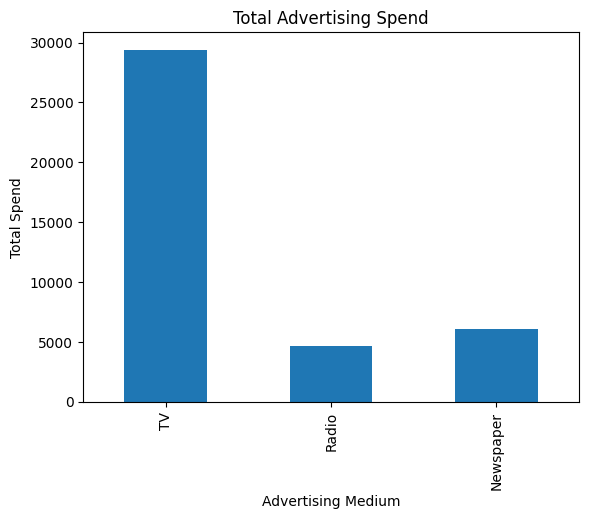

In [16]:
import matplotlib.pyplot as plt

total_spend = df[['TV', 'Radio', 'Newspaper']].sum()

total_spend.plot(kind='bar')

plt.title("Total Advertising Spend")
plt.xlabel("Advertising Medium")
plt.ylabel("Total Spend")
plt.show()

In [17]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)
print("Approximate Accuracy:", round(r2 * 100, 2), "%")

R² Score: 0.899438024100912
Approximate Accuracy: 89.94 %
